In [2]:
!pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
    --------------------------------------- 2.1/102.4 MB 17.6 MB/s eta 0:00:06
   ------ --------------------------------- 15.5/102.4 MB 50.4 MB/s eta 0:00:02
   ---------- ----------------------------- 27.3/102.4 MB 54.6 MB/s eta 0:00:02
   ------------- -------------------------- 34.6/102.4 MB 52.1 MB/s eta 0:00:02
   ----------------- ---------------------- 44.0/102.4 MB 47.7 MB/s eta 0:00:02
   ------------------- -------------------- 49.5/102.4 MB 44.2 MB/s eta 0:00:02
   ---------------------- ----------------- 58.7/102.4 MB 43.9 MB/s eta 0:00:01
   -------------------------- ------------- 67.4/102.4 MB 43.7 MB/s eta 0:00:01
   ----------------------------- ---------- 75.8/102.4 MB 43.4 MB/s eta 0:00:01
   -------------------------------- ------- 82.3/102.4 MB 42.3 MB/s eta 0:00:01
   ---------------------------------- ----- 88.6/102.4 MB 41.4 MB/s eta 0:00:01
   ------------------------------------- -- 95.2/1

In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
# ====== Загрузка ======
df = pd.read_csv("social.csv")

In [5]:
# Целевая переменная
target = "Healthcare_1"

In [6]:
# Признаки
features = ["Social_1", "Social_2", "Social_3", 
            "Helthcare_2", "Price", "DistrictId"]

In [7]:
# Категориальные признаки
cat_features = ["DistrictId"]

In [8]:
# Разделяем данные
train_df = df[df[target].notna()].copy()
test_df  = df[df[target].isna()].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]

In [9]:
# ==== Подготовка CatBoost Pool ====
train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  cat_features=cat_features)

In [10]:
# ====== Модель CatBoost ======
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

In [11]:
model.fit(train_pool)

0:	learn: 1002.8852626	total: 165ms	remaining: 4m 7s
200:	learn: 152.3719452	total: 6.69s	remaining: 43.2s
400:	learn: 77.6542503	total: 13.2s	remaining: 36.1s
600:	learn: 49.8685043	total: 19.6s	remaining: 29.4s
800:	learn: 36.1760047	total: 26.1s	remaining: 22.7s
1000:	learn: 28.0664630	total: 32.5s	remaining: 16.2s
1200:	learn: 23.2286664	total: 39s	remaining: 9.72s
1400:	learn: 19.7966486	total: 45.5s	remaining: 3.22s
1499:	learn: 18.6781511	total: 48.7s	remaining: 0us


In [12]:
# ====== Предсказание пропущенных значений ======
preds = model.predict(test_pool)

df["Healthcare_1_filled"] = df["Healthcare_1"]
df.loc[df[target].isna(), "Healthcare_1_filled"] = preds

print("Готово! Пропуски в Healthcare_1 заполнены в колонке Healthcare_1_filled.")


Готово! Пропуски в Healthcare_1 заполнены в колонке Healthcare_1_filled.


In [13]:
# ====== Оценка качества ======
train_preds = model.predict(train_pool)

print("R2:", r2_score(y_train, train_preds))
print("MAE:", mean_absolute_error(y_train, train_preds))

R2: 0.9982933521419992
MAE: 8.217833234888257


In [14]:
# ====== Важность признаков ======
print("\nFeature Importance:")
imp = model.get_feature_importance(train_pool)
for f, w in sorted(zip(features, imp), key=lambda x: -x[1]):
    print(f"{f}: {w:.2f}")



Feature Importance:
Social_2: 27.08
Social_3: 21.69
Social_1: 18.27
Helthcare_2: 16.78
DistrictId: 16.02
Price: 0.15


In [15]:
df.head(50)

,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Price,DistrictId,Healthcare_1_filled
0,33,7976,5,NaN,0,184966.930730,35,1020.219959
1,46,10309,1,240.0,1,300009.450063,41,240.000000
2,34,7759,0,229.0,1,220925.908524,53,229.000000
3,23,5735,3,1084.0,0,175616.227217,58,1084.000000
4,35,5776,1,2078.0,2,150226.531644,99,2078.000000
5,35,7715,4,990.0,0,215898.447742,59,990.000000
6,20,4386,14,NaN,1,296021.204377,154,1419.075428
7,6,1437,3,NaN,0,221244.156664,74,318.315892
8,1,264,0,NaN,0,229102.795999,1,74.195660
9,6,1437,3,NaN,0,95380.220993,23,271.383147


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

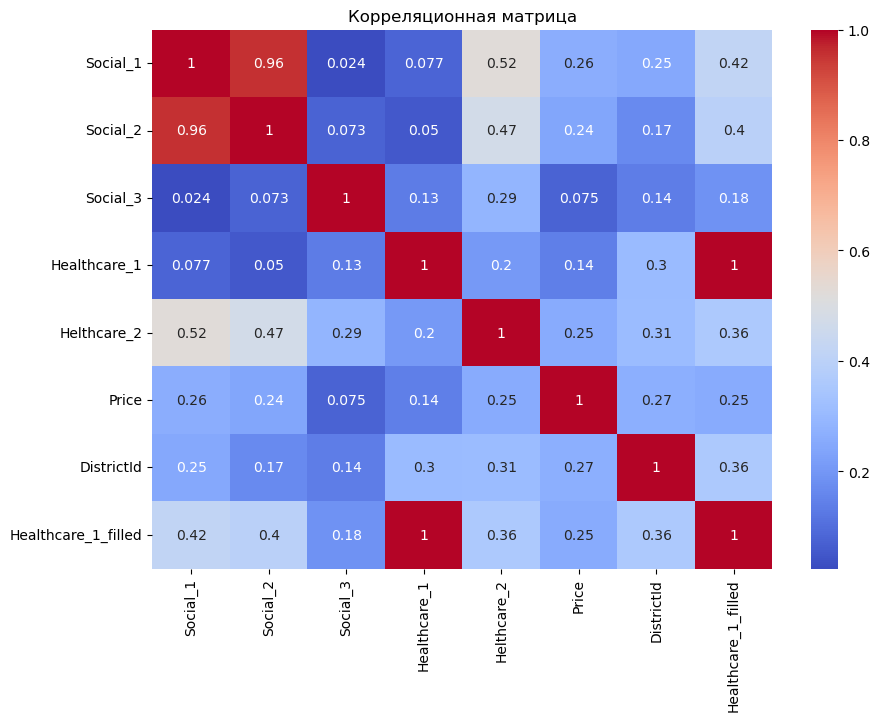

In [17]:
# --- Корреляции ---
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()